In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cns.utils.assemblies import hg19
from cns.utils.files import load_cna, load_samples
from cns.process.binning import add_derived, mean_bins
from cns.analyze.genome import fig_genome_groups, fig_genome

In [3]:
pcawg_3MB = load_cna("./out/PCAWG_bin_3MB.tsv")
tracerx_3MB = load_cna("./out/TRACERx_bin_3MB.tsv")
tcga_3MB = load_cna("./out/TCGA_hg19_bin_3MB.tsv")

In [4]:
pcawg_samples = load_samples("./out/PCAWG_samples.tsv")
tracerx_samples = load_samples("./out/TRACERx_samples.tsv")
tcga_samples = load_samples("./out/TCGA_hg19_samples.tsv")

In [5]:
def get_cns_for_type(cns, samples, type):
	ids = samples.query(f"type == '{type}'").index
	select_cns = cns.set_index("sample_id").loc[ids].reset_index()
	return select_cns

In [6]:
pcawg_samples["type"].value_counts()

type
Liver-HCC              327
Prost-AdenoCA          286
Panc-AdenoCA           241
Breast-AdenoCA         198
CNS-Medullo            146
Kidney-RCC             144
Ovary-AdenoCA          113
Lymph-BNHL             107
Skin-Melanoma          107
Eso-AdenoCA             98
Lymph-CLL               95
CNS-PiloAstro           89
Panc-Endocrine          85
Stomach-AdenoCA         75
ColoRect-AdenoCA        60
Head-SCC                57
Myeloid-MPN             51
Uterus-AdenoCA          51
Thy-AdenoCA             48
Lung-SCC                48
Kidney-ChRCC            45
CNS-GBM                 41
Bone-Osteosarc          38
Lung-AdenoCA            38
Biliary-AdenoCA         34
Bladder-TCC             23
SoftTissue-Liposarc     19
Cervix-SCC              18
CNS-Oligo               18
Myeloid-AML             16
Bone-Benign             16
SoftTissue-Leiomyo      15
Breast-LobularCA        13
Bone-Epith              10
Myeloid-MDS              3
Breast-DCIS              3
Cervix-AdenoCA         

In [7]:
tracerx_luad = mean_bins(get_cns_for_type(tracerx_3MB, tracerx_samples, "LUAD"), hg19)
tracerx_lusc = mean_bins(get_cns_for_type(tracerx_3MB, tracerx_samples, "LUSC"), hg19)
tcga_luad = mean_bins(get_cns_for_type(tcga_3MB, tcga_samples, "LUAD"), hg19)
tcga_lusc = mean_bins(get_cns_for_type(tcga_3MB, tcga_samples, "LUSC"), hg19)

In [8]:
pcawg_luad = mean_bins(get_cns_for_type(pcawg_3MB, pcawg_samples, "Lung-AdenoCA"), hg19)
pcawg_lusc = mean_bins(get_cns_for_type(pcawg_3MB, pcawg_samples, "Lung-SCC"), hg19)

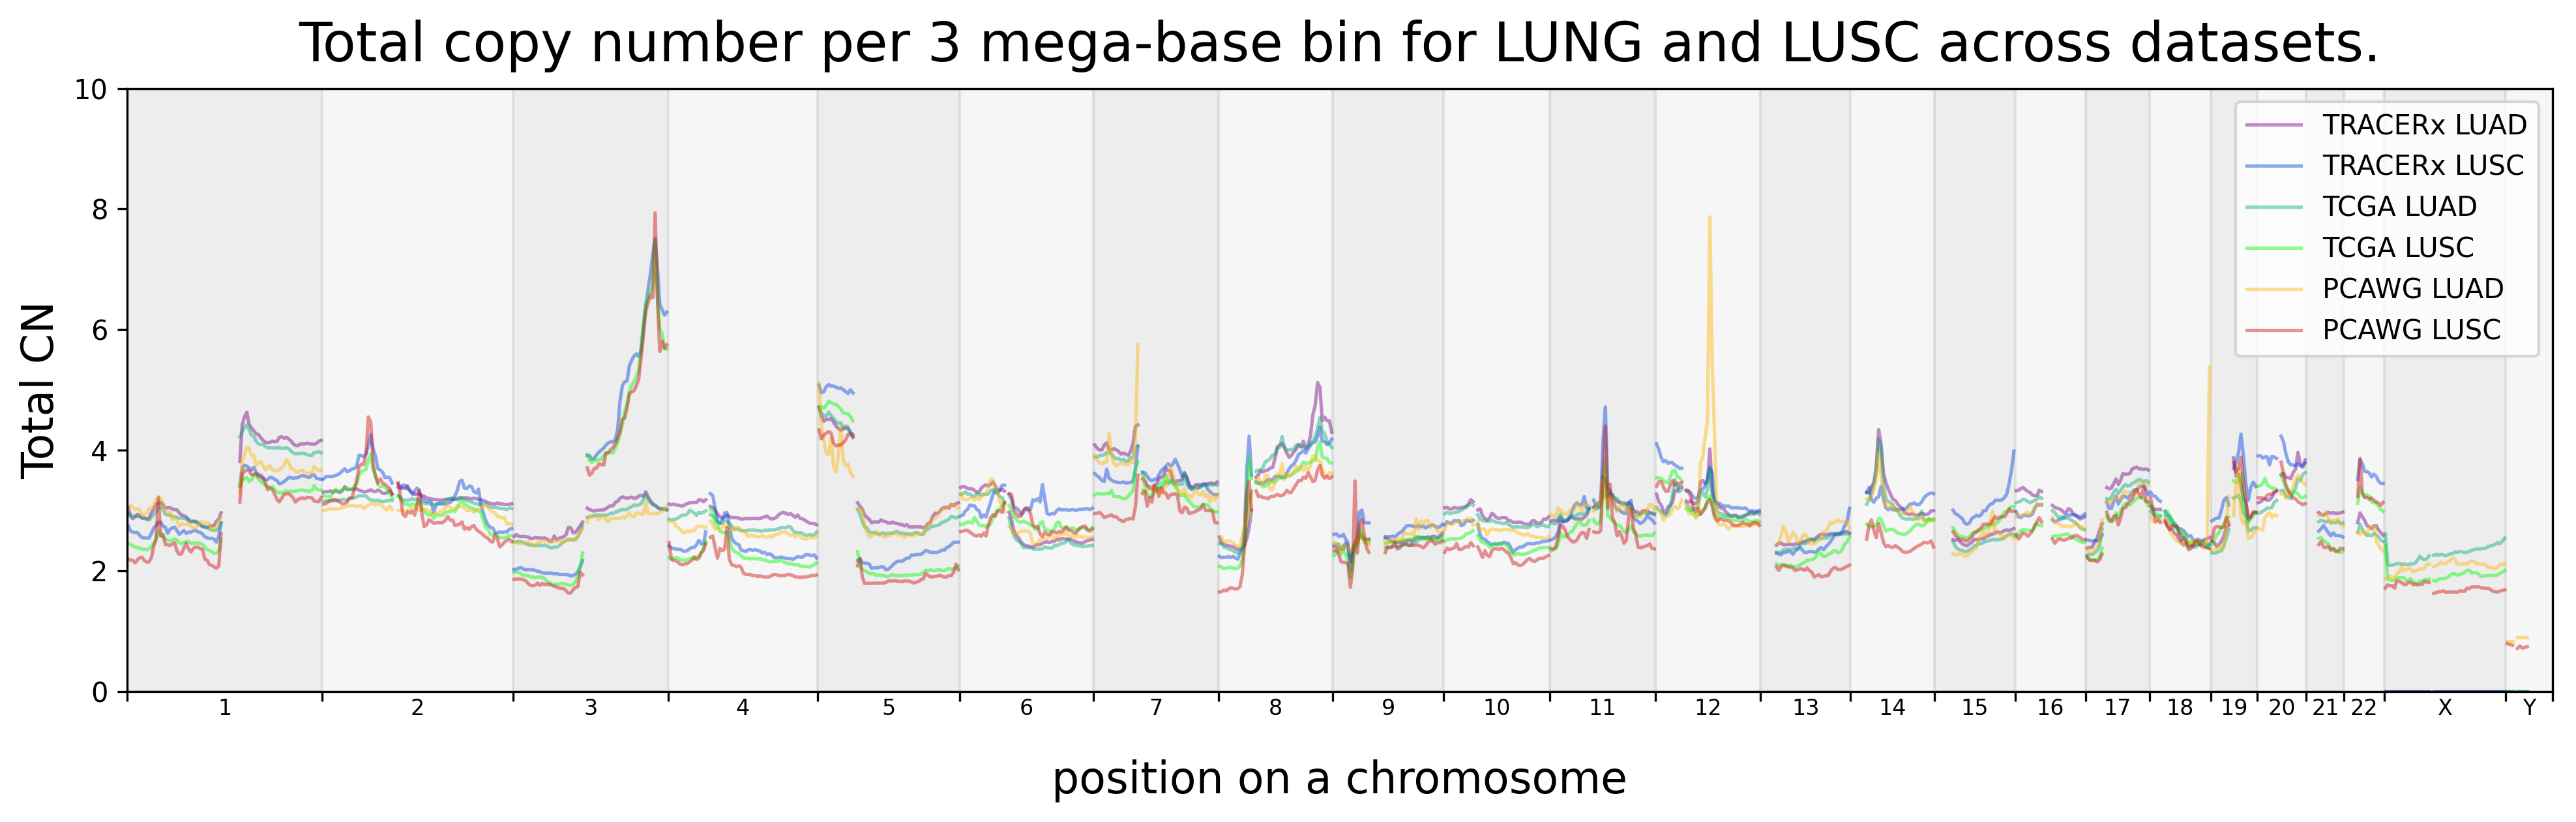

In [9]:
groups = [tracerx_luad, tracerx_lusc, tcga_luad, tcga_lusc, pcawg_luad, pcawg_lusc]  
labels = ["TRACERx LUAD", "TRACERx LUSC", "TCGA LUAD", "TCGA LUSC", "PCAWG LUAD", "PCAWG LUSC"]
fig, ax = fig_genome_groups(groups, labels, hg19, alpha=.8, size=0.25, dpi=300)
ax.set_title("Total copy number per 3 mega-base bin for LUNG and LUSC across datasets.", pad=10)
ax.title.set_size(20)  
# save figure as a pdf
plt.savefig("./out/fig_genome_groups.pdf", bbox_inches='tight')

In [10]:
tcga_samples

,sex,type,chrom_count,chrom_missing,cover_bases_aut,cover_bases_sex,cover_bases_tot,cover_frac_aut,cover_frac_sex,cover_frac_tot,...,ane_total_cn_aut,ane_major_cn_frac_aut,ane_minor_cn_frac_aut,ane_total_cn_frac_aut,ane_major_cn_sex,ane_minor_cn_sex,ane_total_cn_sex,ane_major_cn_frac_sex,ane_minor_cn_frac_sex,ane_total_cn_frac_sex
sample_id,,,,,,,,,,,,,,,,,,,,,
TCGA-02-0001,xx,GBM,23,[],2782224664,155065370,2937290034,0.965704,0.998679,0.967390,...,1557120048,0.491419,0.213112,0.540473,0,155270560,155270560,0.000000,1.000000,1.000000
TCGA-02-0003,xy,GBM,23,['chrY'],2793437134,155064607,2948501741,0.969596,0.722427,0.952458,...,453966781,0.056043,0.101649,0.157571,59373566,3030404,62403970,0.276614,0.014118,0.290732
TCGA-02-0006,xx,GBM,23,[],2770784614,155065370,2925849984,0.961733,0.998679,0.963622,...,2530144631,1.000000,0.953584,0.878207,155270560,155270560,155270560,1.000000,1.000000,1.000000
TCGA-02-0007,xx,GBM,23,[],2793344181,155061347,2948405528,0.969563,0.998653,0.971051,...,567884666,0.063999,0.215961,0.197111,0,903957,903957,0.000000,0.005822,0.005822
TCGA-02-0009,xx,GBM,23,[],2793221390,155065370,2948286760,0.969521,0.998679,0.971012,...,473323454,0.077266,0.088670,0.164289,0,0,0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-ZS-A9CF-a,xy,LIHC,23,['chrY'],2770151629,155023694,2925175323,0.961513,0.722236,0.944923,...,660402545,0.075305,0.156523,0.229224,60280245,2698815,62979060,0.280838,0.012573,0.293412
TCGA-ZS-A9CG,xy,LIHC,23,['chrY'],2759750750,155054728,2914805478,0.957903,0.722380,0.941573,...,2834177752,1.000000,0.925722,0.983737,214644126,2689730,214644126,1.000000,0.012531,1.000000
TCGA-ZT-A8OM,xx,THYM,23,[],2793457331,155065370,2948522701,0.969603,0.998679,0.971089,...,164156,0.000000,0.000057,0.000057,0,0,0,0.000000,0.000000,0.000000


(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

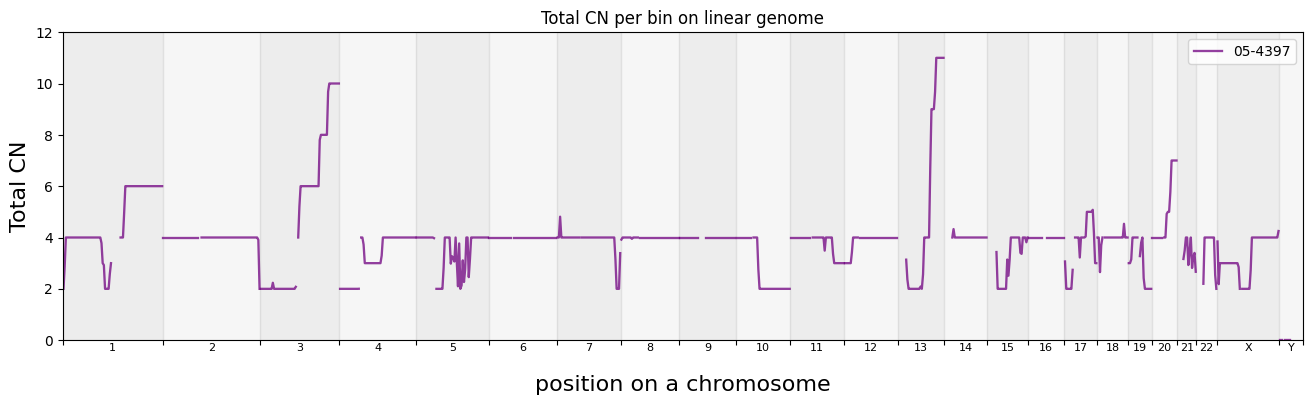

In [11]:
tracer_x_sel_ids = list(tcga_samples.query("type == 'LUAD'").index[9:10])

groups = []
for id in tracer_x_sel_ids:
	select_cns = tcga_3MB.set_index("sample_id").loc[id].reset_index()
	groups.append(add_derived(select_cns, hg19))

shorten = [name[-7:] for name in tracer_x_sel_ids]
fig_genome_groups(groups, shorten, hg19, alpha=.75, max_cn=12)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

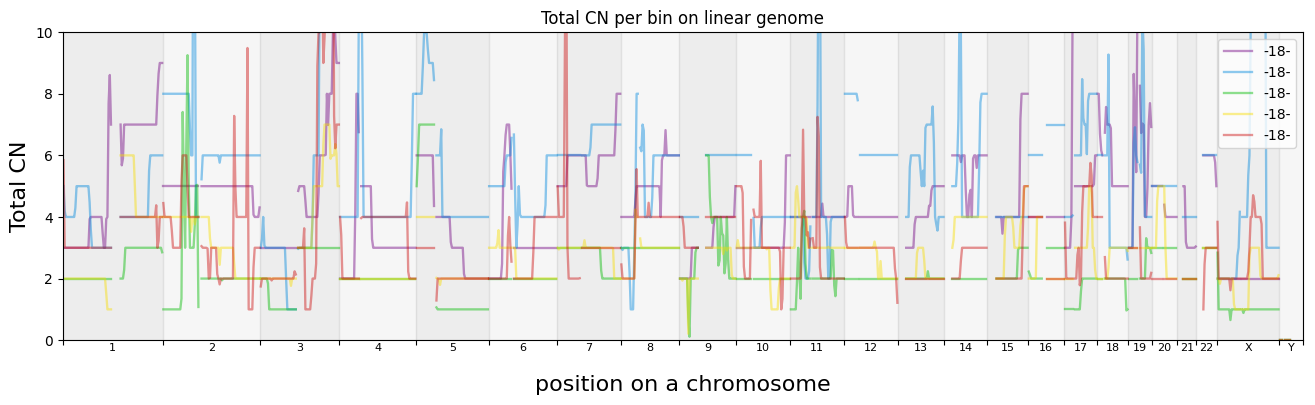

In [12]:
tracer_x_sel_ids = list(tcga_samples.query("type == 'LUSC'").index[5:10])

groups = []
for id in tracer_x_sel_ids:
	select_cns = tcga_3MB.set_index("sample_id").loc[id].reset_index()
	groups.append(add_derived(select_cns, hg19))

shorten = [name[4:8] for name in tracer_x_sel_ids]
fig_genome_groups(groups, shorten, hg19, alpha=.75)